# DiSCo Python Test
Dieses Notebook testet die übersetzte Python-Version (`disco.py`) mit dem `dube` Datensatz, der auch in der R-Vignette (`Dube2019.Rmd`) verwendet wird.

In [1]:
import pandas as pd
import numpy as np
import pyreadr
import sys
import os
import matplotlib.pyplot as plt

# Pfad hinzufügen, damit wir als Modul importieren können
sys.path.append(os.path.abspath('..'))

from python.disco import DiSCo
from python.temp.data import get_contunious_data, get_discrete_data
from python.evaluation.visualization import (plot_fit_quantiles, plot_fit_cdf, plot_fit_copula, plot_fit_joint_contour,
plot_fit_scatter2d)

from python.tea import disco_tea

from python.evaluation.metrics import calculate_pretreatment_fit

## 1. Dube (2019) Daten laden
Wir laden die Daten aus dem R-Package `data/dube.rda`. Laut der Vignette wird `state=2` als Treatment betrachtet und `t0=2003`.

In [ ]:
# Lade die originale R-Datei
result_rda = pyreadr.read_r('../data/dube.rda')
df_raw = result_rda['dube']

# Spalten passend für DiSCo umbenennen
df = df_raw.copy()
df = df.rename(columns={
    'fips': 'id_col',
    'year': 'time_col',
    'adj0contpov': 'y_col'
})

print(f"Datensatz geladen: {len(df)} Zeilen")
df.head()

In [ ]:
print("Initialisiere DiSCo mit Dube-Daten...")  
disco_model = DiSCo(
    df=df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target=2,     # FIPS = 2 (Alaska) als Treatment
    t0=2003,             # Treatment im Jahr 2003
    M=1000,              # Monte Carlo Draws 
    G=100,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    q_max=0.9,            # Entspricht den Parametern in der Vignette
    CI=False,             # Bootstrap-Konfidenzintervalle berechnen
    cl=0.95,             # Konfidenzniveau für Intervalle
    uniform=False,
    perm=False,
    mixture=True
)

result = disco_model.fit()

In [ ]:
plot_fit_cdf(result, show_controls=False)

In [ ]:
pd.Series(result.weights, index=disco_model.controls_id).sort_values(ascending=False).head(5)

In [ ]:
calculate_pretreatment_fit(result)

In [ ]:
tea_res = disco_tea(result, agg="quantileDiff", graph=True )
print(tea_res.summary())

## Paper replication

### Simulated Data

In [ ]:
# Recreation of figure 4 from DiSCo paper
num_controls = 4
sample_size = 1000
seed = 42
synth_df = get_contunious_data(sample_size, num_controls, target_offset=0, dist_control=3, dist_target=4)

fit_synth = DiSCo(
    df=synth_df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
    mixture=False
)
fit_synth = fit_synth.fit()


In [ ]:
# Get the post-treatment period result to see how it fitted
plot_fit_quantiles(fit_synth, show_controls=False)

In [ ]:
plot_fit_cdf(fit_synth, show_controls=False)

In [ ]:
synth_df = get_discrete_data(sample_size, num_controls)

fit_synth_disc = DiSCo(
    df=synth_df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=1000,              # Monte Carlo Draws
    G=1000,              # Grid Size
    num_cores=-1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    q_max=1,
)
fit_synth_disc = fit_synth_disc.fit()

In [ ]:
# Get the post-treatment period result to see how it fitted
period_res = fit_synth_disc.results_periods[2.0]  # The post-treatment period
plot_fit_quantiles(fit_synth_disc, show_controls=False)
weights = period_res.DiSCo.weights


### Dube Daten aus 2013

In [ ]:
dube = pd.read_csv('../datasets/dube_combined.csv')
dube_2013 = dube[dube['year'] == 2013].copy()
dube_2013 = dube_2013.dropna(subset=['faminc', 'age']) 

In [ ]:
data = []
for fips, group in dube_2013.groupby('fips'):
    if len(group) < 2000:
        continue # Ignoriere die kleinen states
    group = group.sample(n=2000) # Shuffle und 2000 ziehen
    
    # Pre-treatment (Jahr 1)
    pre = group.iloc[:1000].copy()
    pre['year'] = 1
    
    # Post-treatment (Jahr 2)
    post = group.iloc[1000:].copy()
    post['year'] = 2
    
    data.extend([pre, post])

dube_multi = pd.concat(data, ignore_index=True)
print(f"Number of valid states: {dube_multi['fips'].nunique()}")

In [ ]:
fit_dube_multi = DiSCo(
    df=dube_multi,
    id_col='fips',
    time_col='year',
    y_col=['faminc', 'age'],
    id_col_target=4,       # FIPS = 4 (Beispiel state) als Treatment
    t0=2,                  # Treatment im Jahr 2 (post-treatment)
    M=1000,                # Monte Carlo Draws 
    G=50,                  # Grid Size (Kleiner für multidimensional)
    num_cores=-1,          # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,          # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    mixture=False,
)
fit_dube_multi = fit_dube_multi.fit()

In [ ]:
plot_fit_joint_contour(fit_dube_multi)

In [ ]:
plot_fit_copula(fit_dube_multi)

In [ ]:
plot_fit_cdf(fit_dube_multi)

### Medicaid Dataset

In [ ]:
medicaid = pd.read_csv('../datasets/medicaid.csv')

In [ ]:
medicaid['STATEFIP'].value_counts()

### Simulierte Daten

In [84]:
# Super realistische Schwankungen (nahe der vorgegebenen Baseline)
test_df = get_contunious_data(1000, 10, dim=2, base_corr=0.6, corr_drift=0.6)


In [ ]:
from utils import sample_counterfactual_distribution


In [73]:
fit_2D_sw = DiSCo(
    df=test_df,
    id_col='id_col',
    time_col='time_col',
    y_col=['y_col_1', 'y_col_2'],
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=100,              # Monte Carlo Draws
    G=10,
    B=50,                            # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=False,
    perm=False,
    seed=None,
    mixture=False,
    method='sliced',
    #n_slices=100
)
fit_2D_sw = fit_2D_sw.fit()

In [ ]:
fit_df = fit_2D_sw.params.df.copy()
df_controls = fit_df.loc[fit_df['id_col'].isin(fit_2D_sw.control_ids),:]
df_controls = df_controls[df_controls['time_col'] < fit_2D_sw.params.t0]

grid = fit_2D_sw.results_periods[1].target.grid
sample_counterfactual_distribution(df_controls,
                                    fit_2D_sw.weights, 
                                    grid, 
                                    num_samples=None)

TypeError: sample_counterfactual_distribution() got multiple values for argument 'num_samples'

In [83]:
calculate_pretreatment_fit(fit_2D_sw).metrics_per_period[1]

{'w1': 2.4295158283360228,
 'energy_divergence': 9.173379913909674,
 'ks_stat': [np.float64(0.125), np.float64(0.126)],
 'mean_diff': [np.float64(0.27867486703174393),
  np.float64(1.0690662946692644)],
 'cov_error': 23.22146114900652}

In [71]:
pd.Series(fit_2D_sw.results_periods[1.0].DiSCo.weights, index=fit_2D_sw.control_ids).sort_values(ascending=False).head(5)

4    0.235956
3    0.209623
2    0.205483
7    0.193981
5    0.080417
dtype: float64

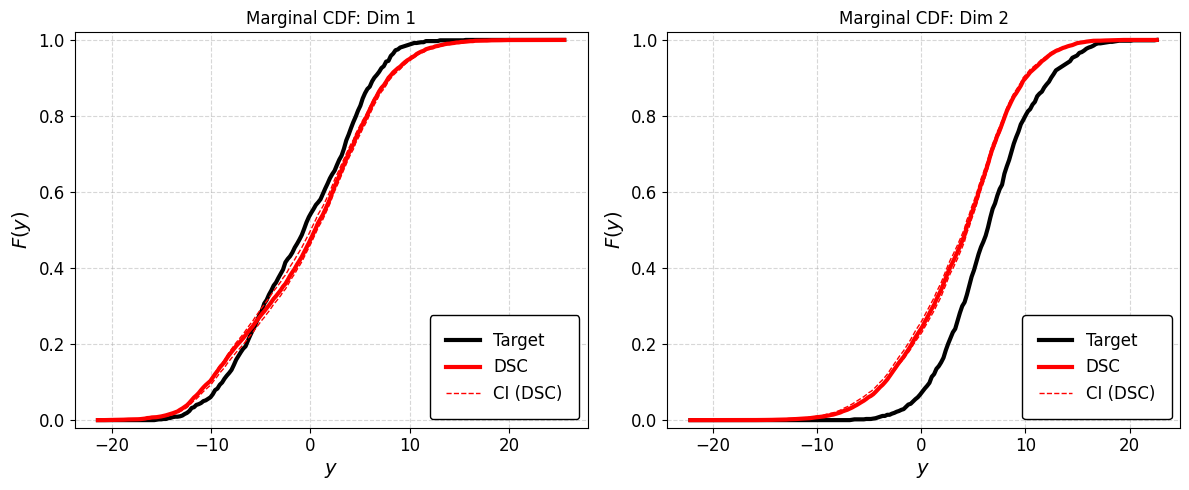

In [51]:
plot_fit_cdf(fit_2D_sw, show_controls=False)

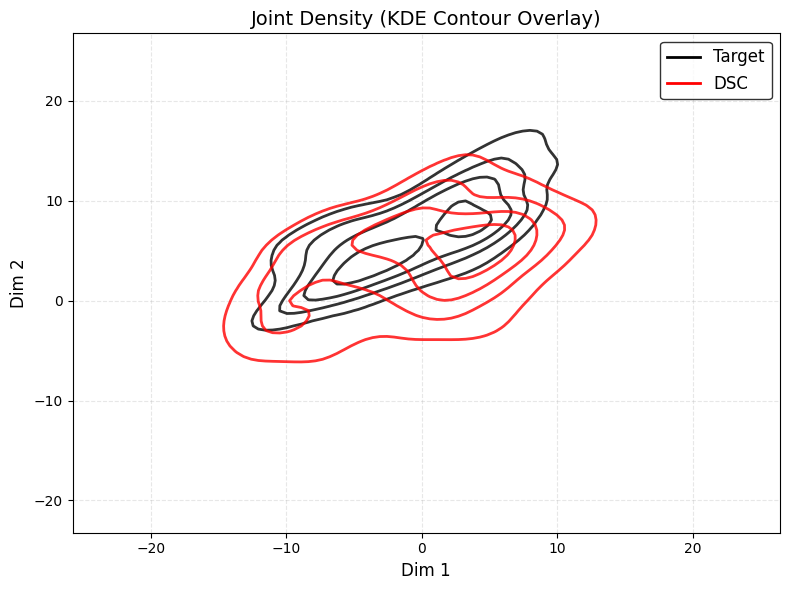

In [53]:
plot_fit_joint_contour(fit_2D_sw)

In [22]:
fit_2D_sw = DiSCo(
    df=test_df,
    id_col='id_col',
    time_col='time_col',
    y_col=['y_col_1', 'y_col_2'],
    id_col_target='0',     # Spalte '0' als Treatment
    t0=9999,             # Post-treatment ab Jahr 9999 (also 9998 ist pre-treatment)
    M=100,              # Monte Carlo Draws
    G=10,
    B=50,                            # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    CI=True,
    perm=False,
    seed=None,
    mixture=False,
    method='sliced',
    #n_slices=100
)
fit_2D_sw = fit_2D_sw.fit()

In [64]:
calculate_pretreatment_fit(fit_2D_sw).metrics_per_period[1]

{'w1': 2.2448047826371105,
 'energy_divergence': 8.174417332602836,
 'ks_stat': [np.float64(0.06), np.float64(0.123)],
 'mean_diff': [np.float64(0.18762188628515286),
  np.float64(0.0555352643205369)],
 'cov_error': 27.253658210351528}

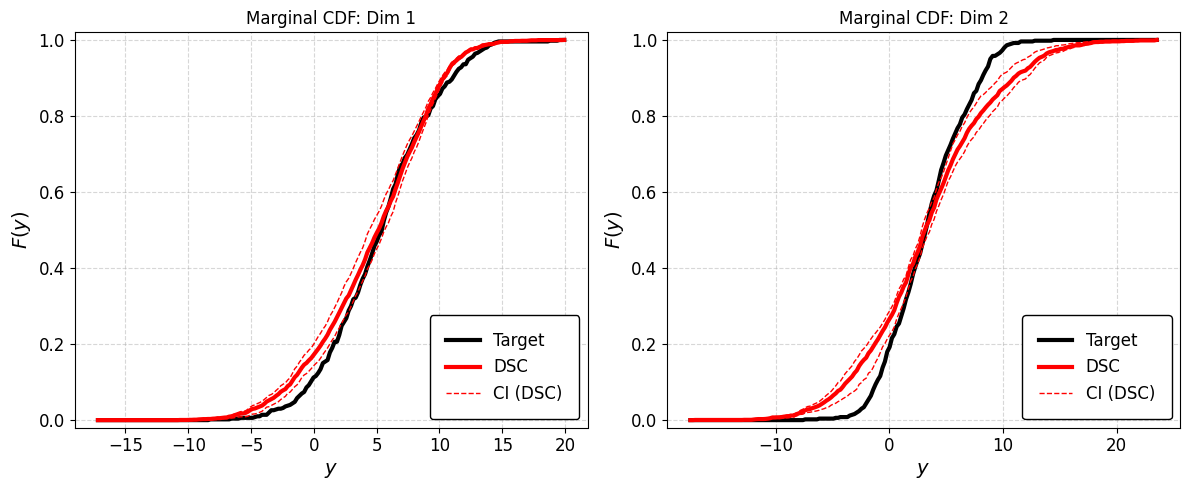

In [24]:
plot_fit_cdf(fit_2D_sw, show_controls=False)

# REAL DATASETS

In [65]:
dube_large = pd.read_csv('../datasets/dube_combined.csv')

In [48]:
dube_small = pd.read_csv('../datasets/dube_small.csv')

In [5]:
matched = pd.read_stata('../datasets/data3/data/matchedCPS_1979_2016.dta')

In [3]:
reader = pd.io.stata.StataReader('../datasets/data3/data/matchedCPS_1979_2016.dta')
labels = reader.variable_labels()

# In ein DataFrame umwandeln für die Suche
df_meta = pd.DataFrame(list(labels.items()), columns=['Variable', 'Beschreibung'])

# Suche nach Lohn- und Stundenvariablen
search = df_meta[df_meta['Variable'].str.contains('wage|hour|earn', case=False)]
print(search)

              Variable                             Beschreibung
17            uhours_1                         (dp) Usual hours
18            earnhr_1                   (dp) Earnings per hour
19           uearnwk_1             (dp) Usual earnings per week
20            earnwt_1  (dp) Earnings weight for all races x100
21           uhourse_1                       (e&dp) Usual hours
23           earnhre_1                 (e&dp) Earnings per hour
24           earnwke_1                 (e&dp) Earnings per week
53              wage_1                                         
54      hoursimputed_1                                         
55   earningsimputed_1                                         
56       wageimputed_1                                         
58         orig_wage_1                                         
85              uhours                         (dp) Usual hours
86              earnhr                   (dp) Earnings per hour
87             uearnwk             (dp) 

In [53]:
matched.groupby(['year', 'statenum'])['earnwke'].count().sort_values() 

year  statenum
1986  35.0         121
      8.0          127
      5.0          139
      41.0         140
      56.0         144
                  ... 
1980  6.0         5085
1984  6.0         5191
1981  6.0         5195
1983  6.0         5208
1982  6.0         5210
Name: earnwke, Length: 1887, dtype: int64

In [54]:
matched.shape

(3642039, 136)